# H2 / 6-31G · K=4 —— Frozen-State NES-VMC（Route B 冻结流形）

基于 `文档/NES-VMC冻结策略/1001-冻结方案.md` 的 **Frozen-state NES manifold** 策略：

1. **Stage 0**：标准 NES-VMC（K=4 列，实参数 FFNN Ansatz，与 `H2_631G_8Qbit_K4_Ansatz_A_RealFFNN.ipynb` 相同）训练到 φ₀ 收敛；
2. **冻结**：φ₀ = Σⱼ v₀ⱼ ψⱼ 以 stop-gradient 常量列进入新流形 B = [φ₀, ψ₁', ψ₂', ψ₃']；
3. **Stage 1（frozen）**：采样分布 |det[φ₀, ψ₁', ψ₂', ψ₃']|²，只训练 3 个 fresh active 列（行列式自动消除与 φ₀ 线性相关的冗余方向 = implicit projection）；
4. **对照组（control）**：不冻结，4 列全部继续训练相同步数；
5. **诊断**：16 维全空间精确求和（φ₀ 保真度漂移 / block 能级 / FCI 重叠）。

核心实现见 `NES_VMC_frozen_routeB.py`。

In [1]:
import pickle, time, numpy as np, matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)

import NES_VMC_frozen_routeB as R
from H2_6_31G import E_fcis, K

# 小规模参数（notebook 演示用；完整复现请运行脚本默认参数）
class Cfg:
    n_iter0, n_iter1, n_samples = 300, 200, 200
    n_chains, lr, diag_shift = 16, 0.1, 0.1
    clip_norm, per_param_clip, reset_period, diag_every = 20.0, 0.5, 10, 25
R.N_CHAINS_G = Cfg.n_chains

import logging
logger = logging.getLogger("FrozenRouteB_nb")
logger.setLevel(logging.INFO)
logger.propagate = False
h = logging.StreamHandler()
h.setFormatter(logging.Formatter("%(message)s"))
logger.addHandler(h)

states, H, evals, evecs = R.build_exact_reference()
print("稠密 H 低段能级:", evals[:4])

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

H2 分子基本信息
HF energy = -0.99749729 Ha
Total electrons = (1, 1)
Total basis functions = 4
H₂ FCI 基准能量
E0 = -1.05434745 Ha  |  激发能: 0.0000 eV
E1 = -0.95790573 Ha  |  激发能: 2.6243 eV
E2 = -0.66895227 Ha  |  激发能: 10.4871 eV
E3 = -0.55140192 Ha  |  激发能: 13.6859 eV
E4 = -0.02803278 Ha  |  激发能: 27.9275 eV
E5 = -0.01450343 Ha  |  激发能: 28.2956 eV
E6 = -0.00518297 Ha  |  激发能: 28.5492 eV
E7 = 0.02397075 Ha  |  激发能: 29.3425 eV
E8 = 0.23432390 Ha  |  激发能: 35.0666 eV
E9 = 0.25720575 Ha  |  激发能: 35.6892 eV
E10 = 0.49958128 Ha  |  激发能: 42.2846 eV
E11 = 0.50024484 Ha  |  激发能: 42.3026 eV



HF reference state: [0 0 0 1 0 0 0 1]


single_edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


稠密 H 低段能级: [-1.05434745 -0.95790573 -0.66895227 -0.55140192]


In [2]:
s0 = R.run_stage0(logger, Cfg, states, H, evecs)
print("Stage0 λ =", s0["lam"])

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


[Stage0 0] loss=0.840558 | E_L eig=[-0.50217863 -0.01837953] | exact=[-0.61284814 -0.1193598 ]


[Stage0 24] loss=-2.699731 | E_L eig=[-1.04314059 -0.94924097] | exact=[-1.04486244 -0.95070735]


[Stage0 49] loss=-3.166821 | E_L eig=[-1.04559734 -0.9512849 ] | exact=[-1.0459446  -0.95261763]


[Stage0 74] loss=-3.171761 | E_L eig=[-1.04499897 -0.95427759] | exact=[-1.04525454 -0.95414335]


...

[Stage0 274] loss=-3.204816 | E_L eig=[-1.04718002 -0.95413427] | exact=[-1.04818073 -0.95458426]


[Stage0 299] loss=-3.207045 | E_L eig=[-1.05158006 -0.95232049] | exact=[-1.04942911 -0.95299954]


Stage0 耗时 131.3s


Stage0 广义本征 λ=[-1.04758448 -0.95382406 -0.66196494 -0.54491189] | φ0 保真(对精确基态)=0.996148


Stage0 λ = [-1.04758448 -0.95382406 -0.66196494 -0.54491189]


In [3]:
ctl = R.run_control(logger, Cfg, s0, states, H, evecs)
frz = R.run_frozen(logger, Cfg, s0, states, H, evecs)

[Control 0] loss=-3.206684 | exact=[-1.04970897 -0.95232367] | φ0 漂移保真=0.999471


[Control 24] loss=-3.215614 | exact=[-1.04883764 -0.95244742] | φ0 漂移保真=0.999413


[Control 49] loss=-3.199736 | exact=[-1.04893304 -0.95158376] | φ0 漂移保真=0.999501


[Control 74] loss=-3.195290 | exact=[-1.04933642 -0.94952954] | φ0 漂移保真=0.998842


[Control 99] loss=-3.210182 | exact=[-1.04948517 -0.94947857] | φ0 漂移保真=0.999352


...

[Frozen 124] loss=-3.202986 | E_L eig=[-1.04840279 -0.95688638] | block λ=[-1.04940, -0.95180] | φ0 保真(对FCI基态)=0.996148


[Frozen 149] loss=-3.192977 | E_L eig=[-1.05020183 -0.94972552] | block λ=[-1.04940, -0.95233] | φ0 保真(对FCI基态)=0.996148


[Frozen 174] loss=-3.202753 | E_L eig=[-1.05134833 -0.95491209] | block λ=[-1.04940, -0.95286] | φ0 保真(对FCI基态)=0.996148


[Frozen 199] loss=-3.193975 | E_L eig=[-1.04759645 -0.95054965] | block λ=[-1.04940, -0.95310] | φ0 保真(对FCI基态)=0.996148


Frozen 耗时 99.8s


In [4]:
# ---- 最终精确对比 ----
from NES_VMC_V1 import create_single_machine_gauge_fixed
from H2_6_31G import Hatree_Fock
ctl_sms = [create_single_machine_gauge_fixed(a, Hatree_Fock)[0] for a in s0["total_ansatz"].single_ansatz_list]
Bc = R.gauge_fixed_basis_vectors(ctl_sms, [ctl["total_params"]["single_ansatz_list"][j] for j in range(4)], states)
ana_c = R.exact_subspace_analysis(Bc, H, evecs)
Ba = R.gauge_fixed_basis_vectors(frz["active_sms"], list(frz["active_params"]), states)
blk_f = R.exact_frozen_block_analysis(frz["phi0_vec"], Ba, H, evecs)

print("FCI          :", np.round(E_fcis[:4], 6))
print("[Control] λ  :", np.round(ana_c["lam"], 6))
print("[Frozen ] λ  :", np.round(np.concatenate([[blk_f["e_phi0"]], blk_f["lam_active"]]), 6))
print("[Frozen ] φ0 对 FCI 基态保真度 =", round(blk_f["phi0_fid_fci"], 6), "（构造性严格不变）")
print("[Control] φ0 漂移后对初始 φ0 保真度 =", round(R.fidelity(Bc @ ana_c["V"][:,0], ctl["phi0_ref"]), 6))

FCI          : [-1.054347 -0.957906 -0.668952 -0.551402]
[Control] λ  : [-1.050291 -0.950814 -0.659175 -0.550448]
[Frozen ] λ  : [-1.0494   -0.953104 -0.65411  -0.54529 ]
[Frozen ] φ0 对 FCI 基态保真度 = 0.996148 （构造性严格不变）
[Control] φ0 漂移后对初始 φ0 保真度 = 0.999588


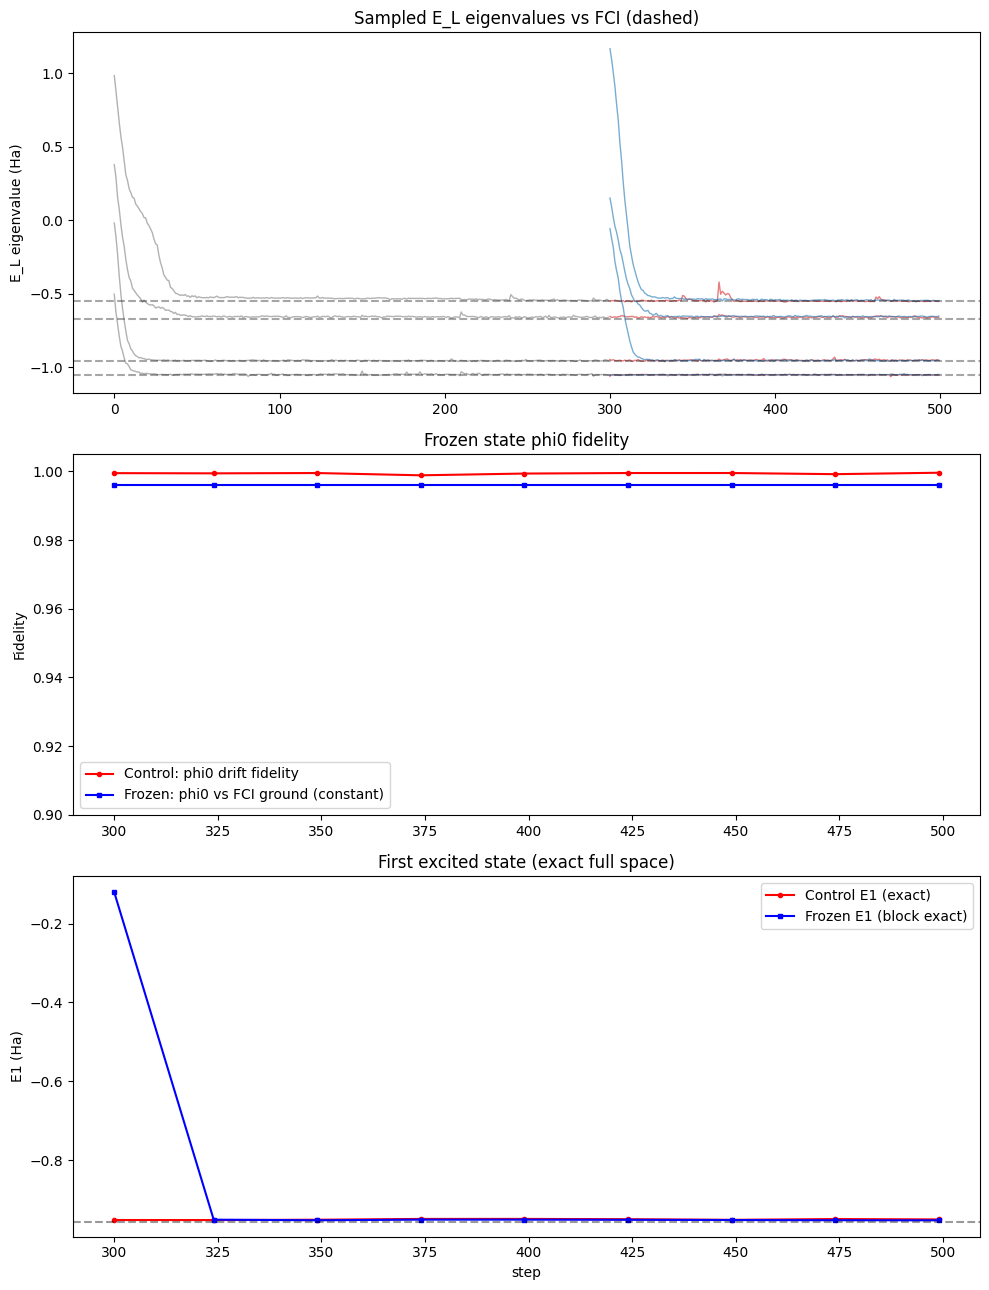

In [5]:
# ---- 训练曲线对比 ----
fig, axs = plt.subplots(3, 1, figsize=(10, 13))

ax0 = axs[0]
for st, hist, color, name in [("S0", s0["hist"], "tab:gray", "Stage 0"),
                              ("C", ctl["hist"], "tab:red", "Control (no freeze)"),
                              ("F", frz["hist"], "tab:blue", "Frozen (Route B)")]:
    off = 0 if st == "S0" else Cfg.n_iter0
    steps = [off + s for s in hist["step"]]
    for lvl in range(4):
        ax0.plot(steps, [e[lvl] for e in hist["E_levels"]], color=color, lw=1, alpha=0.6)
for lvl in range(4):
    ax0.axhline(E_fcis[lvl], color="k", ls="--", alpha=0.35)
ax0.set_ylabel("E_L eigenvalue (Ha)")
ax0.set_title("Sampled E_L eigenvalues vs FCI (dashed)")

ax1 = axs[1]
ax1.plot([Cfg.n_iter0 + s for s, _ in ctl["hist"]["phi0_fid"]], [f for _, f in ctl["hist"]["phi0_fid"]],
         "r-o", ms=3, label="Control: phi0 drift fidelity")
ax1.plot([Cfg.n_iter0 + s for s, _ in frz["hist"]["phi0_fid"]], [f for _, f in frz["hist"]["phi0_fid"]],
         "b-s", ms=3, label="Frozen: phi0 vs FCI ground (constant)")
ax1.set_ylim(0.9, 1.005)
ax1.set_ylabel("Fidelity")
ax1.legend()
ax1.set_title("Frozen state phi0 fidelity")

ax2 = axs[2]
ax2.plot([Cfg.n_iter0 + s for s, _ in ctl["hist"]["eig_exact"]], [l[1] for _, l in ctl["hist"]["eig_exact"]],
         "r-o", ms=3, label="Control E1 (exact)")
ax2.plot([Cfg.n_iter0 + s for s, _ in frz["hist"]["eig_exact"]], [l[1] for _, l in frz["hist"]["eig_exact"]],
         "b-s", ms=3, label="Frozen E1 (block exact)")
ax2.axhline(E_fcis[1], color="k", ls="--", alpha=0.4)
ax2.set_ylabel("E1 (Ha)")
ax2.set_xlabel("step")
ax2.legend()
ax2.set_title("First excited state (exact full space)")
fig.tight_layout()
plt.show()